<a href="https://colab.research.google.com/github/antonyza/multimodal-music-analysis/blob/main/part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Εργασια μαθηματος: Τεχνικές Εξόρυξης Δεδομένων
* Ομαδα:

*   -ΖΑΧΑΡΑΚΗΣ ΑΝΤΩΝΙΟΣ ΑΜ:1115202300047
*   -ΚΑΛΗΣΠΕΡΑΚΗΣ ΕΜΜΑΝΟΥΗΛ ΑΜ:1115202300058




# Dependencies

In [ ]:
!pip install sentence-transformers
!pip install vaderSentiment nltk

# 1. Data Collection

## Data filtering
Keep the songs belonging to 5 genres only.

Those genres are personally picked.

In [ ]:
import pandas as pd

url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/refs/heads/main/Data/id_genres.csv'
my_genres = {'techno', 'country', 'emo', 'reggae', 'jazz'}
chunk_size = 500
filtered_id_genres = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk.dropna(subset=['genres']).copy() # Remove empty lines

    # turn the string of genres (seperated by a comma) into a list with each genre inside
    chunk['genres'] = chunk['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')])

    # keep the songs which their genres (list) intersect with our 5 genres (set) (meaning they have atleast 1 genre from our 5)
    mask = chunk['genres'].apply(lambda genres_list: bool(set(genres_list).intersection(my_genres)))
    chunk = chunk[mask].copy()
    chunk = chunk.rename(columns={"genres": "genre"})

    if not chunk.empty:
        filtered_id_genres.append(chunk)

df_genre = pd.concat(filtered_id_genres, ignore_index=True)
df_genre['genre'] = df_genre['genre'].apply(lambda x: list(dict.fromkeys(x))) # remove duplicate genres

df_genre.head(10)

,id,genre
0,00KSCJkYb8JKa4Y3,"[rock, emo]"
1,0130k7BE0WlWUQLg,[emo]
2,02RGE9FNH65RtMS7,"[trance, electronic, techno]"
3,02S1suSkE5dLFuQh,"[techno, electronic, house]"
4,02cqDSNdfTyOD1AI,"[country, contemporary country, country pop]"
5,03PbpZwYbPjAUBqB,"[house, jazz]"
6,03dA0mAJj48nT2ab,"[k-indie, jazz]"
7,04KIChLwxgxSGbkD,"[jazz, bebop, free jazz]"
8,04La8lPgQyShB5dr,"[blues, soul, jazz]"
9,04SlsdFaQIDnfvr9,"[jazz, jazz fusion]"


Get lyrics from filtered IDs

In [ ]:
from os.path import isfile
import tarfile
import urllib.request

valid_ids = set(df_genre['id']) # keep the ids that we selected from the above filtration only

# Lyrics
url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/main/Data/processed_lyrics.tar.gz'
tar_path = 'processed_lyrics.tar.gz'
urllib.request.urlretrieve(url, tar_path)
lyrics = []

with tarfile.open(tar_path, 'r:gz') as tar:
    for member in tar.getmembers():
        if member.isfile:
            file_id = member.name.split('/')[-1].split('.')[0] # Get ID from file name (remove .txt)

            if file_id in valid_ids:
                file = tar.extractfile(member)
                if file is not None:
                    content = file.read().decode('utf-8')
                    if not content.strip(): # if empty file (no lyrics) then its instrumental
                        content = 'instrumental'

                    lyrics.append({'id': file_id, 'lyrics': content})

df_lyrics = pd.DataFrame(lyrics)
df_lyrics.head()

,id,lyrics
0,YWEVpqA38ezG0dPU,citi shoe clueless blue pay view noman news bl...
1,wzU0Ts9ZAMfwPqAl,get crush sweeti pie day nighttim hear sigh ne...
2,aB5MGbb1KGWRgl2N,tear open packag empti box mean empti box send...
3,M43AP50YsKZVwzbc,could ever let go go beg drive mad say someth ...
4,9Y3mWcWntTVnpXXh,levit round go stop know float away bend break...


Get MFCC stats

In [ ]:
url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/main/Data/id_mfcc_stats.tsv.bz2'
filtered_mfcc_stats = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk[chunk['id'].isin(valid_ids)] # keep from valid song IDs

    if not chunk.empty:
        filtered_mfcc_stats.append(chunk)

df_mfcc_stats = pd.concat(filtered_mfcc_stats, ignore_index=True)
df_mfcc_stats.head()

,id,MFCC000,MFCC001,MFCC002,MFCC003,MFCC004,MFCC005,MFCC006,MFCC007,MFCC008,...,cov_9_9,cov_9_10,cov_9_11,cov_9_12,cov_10_10,cov_10_11,cov_10_12,cov_11_11,cov_11_12,cov_12_12
0,rLfjv8ackxbMBhNm,19.673954,7.374847,-15.109837,-11.847433,0.264044,-18.521660,-7.466475,-2.242330,-13.572355,...,118.288409,5.729727,-4.038114,-14.874527,114.725826,18.788491,-3.406951,97.033048,19.932110,91.360570
1,RLHbq9UXd6cof8Hs,24.639158,-12.822001,-7.392960,-6.209181,-2.153774,-2.274888,-3.867082,-1.193819,-1.405178,...,119.159003,54.040871,33.615619,22.343001,71.530292,38.250632,21.195860,84.002375,47.080897,77.398648
2,j1dQ6TZ3bXn6Ynyt,24.088564,-4.647918,-7.447447,2.401356,-10.061542,1.907399,-5.167847,3.960707,0.971683,...,89.620570,13.797518,8.197030,-7.193006,103.671687,10.435869,-0.186379,83.345863,1.543711,79.169231
3,lRAC2JboOOofsTuE,23.276661,-8.367137,-6.481616,-3.801927,-8.432757,-0.617347,-3.797227,2.791821,1.650162,...,116.750916,29.797668,2.512981,16.170507,103.003531,36.900034,11.820328,87.713964,27.236822,82.561620
4,lrbEv0Tu2jLNlMmD,23.848660,-17.799595,-11.282082,1.395223,-4.768649,1.460606,-0.365338,12.974216,1.694667,...,86.538263,33.140836,5.496330,-0.937074,94.077416,35.472765,-6.621396,72.174649,22.249008,77.636431


Merge and clean the above dataframes into one

In [ ]:
# Merge
temp = pd.merge(df_genre, df_lyrics, on='id', how='inner')
df_merged = pd.merge(temp, df_mfcc_stats, on='id', how='inner')


# Clean
mfcc_cols = [col for col in df_merged.columns if col not in ['id', 'genre', 'lyrics']] # Get all MFCC columns
df_merged['mfcc_stats'] = df_merged[mfcc_cols].values.tolist() # Merge MFCC columns into one column (list)
df_merged = df_merged[['id', 'genre', 'lyrics', 'mfcc_stats']] # keep those 4 columns now

print('Data collection complete with final dataframe shape', df_merged.shape)
df_merged.head(20)

Data collection complete with final dataframe shape (7900, 4)


,id,genre,lyrics,mfcc_stats
0,00KSCJkYb8JKa4Y3,"[rock, emo]",fuck nobodi anybodi somebodi nobodi anybodi on...,"[24.40309333801269, -16.733760833740234, -8.50..."
1,0130k7BE0WlWUQLg,[emo],tire wake tire well trite say tri chang leg ac...,"[23.711875915527344, -12.89763641357422, -5.54..."
2,02RGE9FNH65RtMS7,"[trance, electronic, techno]",fame hold vain letter play game hard love get ...,"[21.82469749450684, -18.16270637512207, -3.055..."
3,02S1suSkE5dLFuQh,"[techno, electronic, house]",instrumental,"[23.05133056640625, -8.015624046325684, -28.29..."
4,02cqDSNdfTyOD1AI,"[country, contemporary country, country pop]",hope day come easi moment pass slow road lead ...,"[24.18877601623535, -10.060083389282228, -10.9..."
5,03PbpZwYbPjAUBqB,"[house, jazz]",go run go run go run go run oh sinn man go run...,"[23.98193550109864, -3.5930917263031006, -5.61..."
6,03dA0mAJj48nT2ab,"[k-indie, jazz]",tire day get home strang unfamiliar feel kind ...,"[23.773550033569336, -4.35776948928833, 0.2221..."
7,04KIChLwxgxSGbkD,"[jazz, bebop, free jazz]",instrumental,"[21.67498588562012, -3.3346436023712163, -5.62..."
8,04La8lPgQyShB5dr,"[blues, soul, jazz]",want slave want work day want true want make l...,"[21.761722564697266, -16.000164031982422, -12...."
9,04SlsdFaQIDnfvr9,"[jazz, jazz fusion]",instrumental,"[23.14767074584961, -17.720975875854492, 2.716..."


## Check for any null/nan values in the final dataframe

In [ ]:
import numpy as np

print('--- Null/NaN Values per column ---')
print(df_merged.isna().sum())

# empty strings in lyrics column
empty_lyrics = df_merged[df_merged['lyrics'].str.strip() == ''].shape[0]
print(f'\nSongs with empty lyric strings: {empty_lyrics}')

# empty mfcc stats lists
empty_mfcc = df_merged[df_merged['mfcc_stats'].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)].shape[0]
print(f'\nSongs with empty MFCC lists: {empty_mfcc}')

# ensure mfcc list is the same length for every song
unique_lengths = df_merged['mfcc_stats'].apply(len).unique()
print(f'Unique list lengths in MFCC lists: {unique_lengths}')

# and also that there are no nan values inside
df_merged['mfcc_nan_count'] = df_merged['mfcc_stats'].apply(lambda x: sum(np.isnan(val) for val in x))
songs_with_nans = df_merged[df_merged['mfcc_nan_count'] > 0].shape[0]
print(f'Songs with NaN values in MFCC lists: {songs_with_nans}')
df_merged = df_merged.drop(columns=['mfcc_nan_count'])

--- Null/NaN Values per column ---
id            0
genre         0
lyrics        0
mfcc_stats    0
dtype: int64

Songs with empty lyric strings: 0

Songs with empty MFCC lists: 0
Unique list lengths in MFCC lists: [104]
Songs with NaN values in MFCC lists: 0


## Also check for any HTML elements

In [ ]:
import re

has_html = df_merged['lyrics'].str.contains(r'<[^>]+>', regex=True, na=False)
html_count = has_html.sum()

print(f"Songs with HTML tags: {html_count}")

Songs with HTML tags: 0


# 2. Feature extraction

## Text embeddings

We opted for a pre-trained BERT-based sentence transformer from HuggingFace (stsb-bert-base) since, in contrast to Word2vec, its contextual and can handle vocalizations (e.g. "la la la" etc...), which are common in songs, thus, providing a better, overall, semantic analysis.

In [ ]:
from sentence_transformers import SentenceTransformer

# load pre-trained bert-based sentence transformer
model = SentenceTransformer('stsb-bert-base')

# create the embeddings from the lyrics directly
lyrics_list = df_merged['lyrics'].tolist()
bert_embeddings = model.encode(lyrics_list, show_progress_bar=True)

# save to dataframe
df_merged['text_embedding'] = bert_embeddings.tolist()

print(f"BERT Embeddings created with shape: {bert_embeddings.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/247 [00:00<?, ?it/s]

BERT Embeddings created with shape: (7900, 768)


## Audio Embeddings

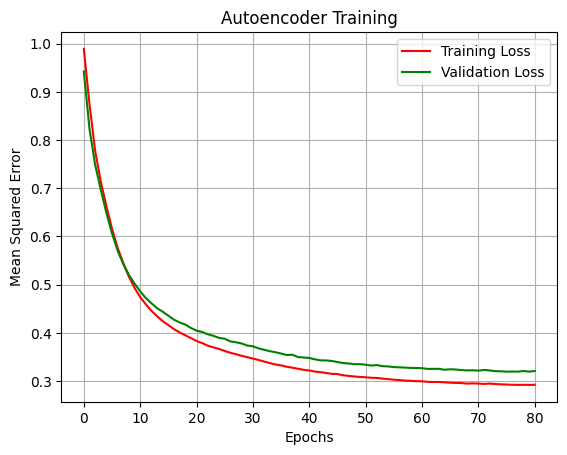

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Final validation loss: 0.32
Auto-encoder embeddings created with shape: (7900,)


In [ ]:
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


# scale the mfcc stats first for the neural network
mfccArray = np.array(df_merged['mfcc_stats'].tolist())
scaler = StandardScaler()
mfccArray = scaler.fit_transform(mfccArray)

input_dim = mfccArray.shape[1] # mfcc list size
encoding_dim = 32  # bottleneck layer = 32



# input (input_dim size)
input_layer = Input(shape=(input_dim,))

# encode (input_dim->64->32 neurons)
encoded = Dense(64, activation='relu')(input_layer)
bottleneck = Dense(encoding_dim, activation='relu')(encoded)

# decode (32-64->input_dim neurons)
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(input_dim, activation='linear')(decoded)

# make model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# train the model
# use early stopping mechanism to stop training when validation loss stops getting better
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = autoencoder.fit(
    mfccArray, mfccArray,
    epochs=100,
    batch_size=256,
    shuffle=True,
    callbacks=[early_stop],
    validation_split=0.2, # avoid overfitting
    verbose=0
)

# plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='green')
plt.title('Autoencoder Training')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# get the model that gives just the bottleneck layer
encoder = Model(inputs=input_layer, outputs=bottleneck)

# extract audio embeddings as a 32-dimension vectors
audio_embeddings = encoder.predict(mfccArray)

# save
df_merged['audio_embedding'] = audio_embeddings.tolist()

print(f'Final validation loss: {min(history.history['val_loss']):.2f}')
print(f'Auto-encoder embeddings created with shape: {df_merged['audio_embedding'].shape}')

#Εξηγηση Εκπαιδευσης Autoencoder
Στο παραπανω διαγραμμα βλεπουμε  την καμπυλη του μεσου τετραγωνικου σφαλματος(MSE) καθως εκπαιδευεται το νευρωνικο δικτυο. Η κοκκινη γραμμη απεικωνιζει το training loss ενω η πρασινη γραμμη το validation loss, σε αυτες τις δυο γραμμες παρατηρουμε πτωση στις πρωτες 10-15 epochs οπου μετα σταθεροποιειται και λιγο πριν τις 100 epochs τερματιζεται.

Η αποτομη πτωση του σφαλματος μας δειχνει οτι το δικτυο προσαρμοζεται και μαθαινει επιτυχως να συμπιεζει τα MFCC χαρακτηριστικα στις 32 διαστασεις του bottleneck layer και τα ανακατασκευαζει ικανοποιητικα

Το μοντελο μας δεν κανει overfitting και γενικευει σωστα χωρις να αποστηθιζει τα δεδομενα εκπαιδευσης, αυτο φαινεται απο το validation loss που ακολουθει την ταση του training loss και δεν εχει αυξητικη ταση

# 3. Exploratory Data Analysis

## WordClouds
Firstly fetch the ID-Tags .csv file and clean it (nan values, alternative names for the same tag and duplicates)

In [ ]:
import html

# map 'incorrect'/alternative tags into one tag name
tags_map = {
    'hiphop': 'hip hop',
    'r&b': 'rnb',
    'rb': 'rnb',
    'rhythm and blues': 'rnb',
    'rythm and blues': 'rnb',
    'r and b': 'rnb',
    'lofi': 'lo fi',
    'indierock': 'indie rock',
    'postrock': 'post rock',
    'postpunk': 'post punk',
    'prog rock': 'progressive rock',
    'poppunk': 'pop punk',
    'kpop': 'k pop',
    'jpop': 'j pop',
    'jrock': 'j rock',
    'synthpop': 'synth pop',
    'drum n bass': 'drum and bass',
    'drumandbass': 'drum and bass',
    'dnb': 'drum and bass',
    'alt rock': 'alternative rock',
    'alt metal': 'alternative metal',
    'alt country': 'alternative country',
    'alt pop': 'alternative pop',
    'alt hip hop': 'alternative hip hop',
    'electropop': 'electro pop',

    '1980s': '80s',
    "80's": '80s',
    '1990s': '90s',
    "90's": '90s',
    '1970s': '70s',
    "70's": '70s',
    '1960s': '60s',
    "60's": '60s',
    '2000s': '00s',
    "00's": '00s',
    '2010s': '10s',
    '010s': '10s',
    "10's": '10s',


    # other languages
    'brasil': 'brazilian',
    'brazil': 'brazilian',
    'rock nacional': 'brazilian rock',
    'rock brasileiro': 'brazilian rock',
    'rock brazuca': 'brazilian rock',
    'rock brasil': 'brazilian rock',
    'suomi': 'finnish',
    'español': 'spanish',
    'espanol': 'spanish',

    # typos
    'eletronic': 'electronic',
    'electronica': 'electronic',
    'eletronica': 'electronic',
    'alternative rocl': 'alternative rock',
    '7soul': 'soul',

    # synonyms
    'ost': 'soundtrack',
    'film score': 'soundtrack',
    'movie song': 'soundtrack'

}

def clean_tags(tags_string):
    raw_tags = str(tags_string).split(',') # get the tags (by comma)

    cleaned_tags = []
    for tag in raw_tags:
        if tag.strip(): # not empty tags (, ,)
            tag = html.unescape(tag) # decode html elements like r&amp;b to r&b
            tag = tag.lower().replace('-', ' ').strip() # lowercase, remove trailing white spaces and remove dashes from hip-hop, lo-fi etc..
            tag = tags_map.get(tag, tag) # clean specific tags from the mappings above

            cleaned_tags.append(tag)

    unique_tags = list(dict.fromkeys(cleaned_tags)) # remove all duplicates
    return unique_tags


url = 'https://raw.githubusercontent.com/antonyza/multimodal-music-analysis/refs/heads/main/Data/id_tags.csv'
filtered_id_tags = []

for chunk in pd.read_csv(url, sep='\t', chunksize=chunk_size):
    chunk = chunk[chunk['id'].isin(valid_ids)] # keep from valid song IDs
    chunk = chunk.dropna(subset=['tags']).copy() # Remove empty lines

    if not chunk.empty:
        chunk['tags'] = chunk['tags'].apply(clean_tags) # clean them

        filtered_id_tags.append(chunk)

df_id_tags = pd.concat(filtered_id_tags, ignore_index=True)

df_id_tags.head(5)

,id,tags
0,00KSCJkYb8JKa4Y3,"[rock, german, progressive, emo]"
1,0130k7BE0WlWUQLg,"[emo, twinkly, florida, emo your face off, bon..."
2,02RGE9FNH65RtMS7,"[trance, electronic, dance, techno]"
3,02S1suSkE5dLFuQh,"[techno, electronic, house]"
4,02cqDSNdfTyOD1AI,"[country, rascal flatts, contemporary country,..."


## Create the wordclouds from 2 genres

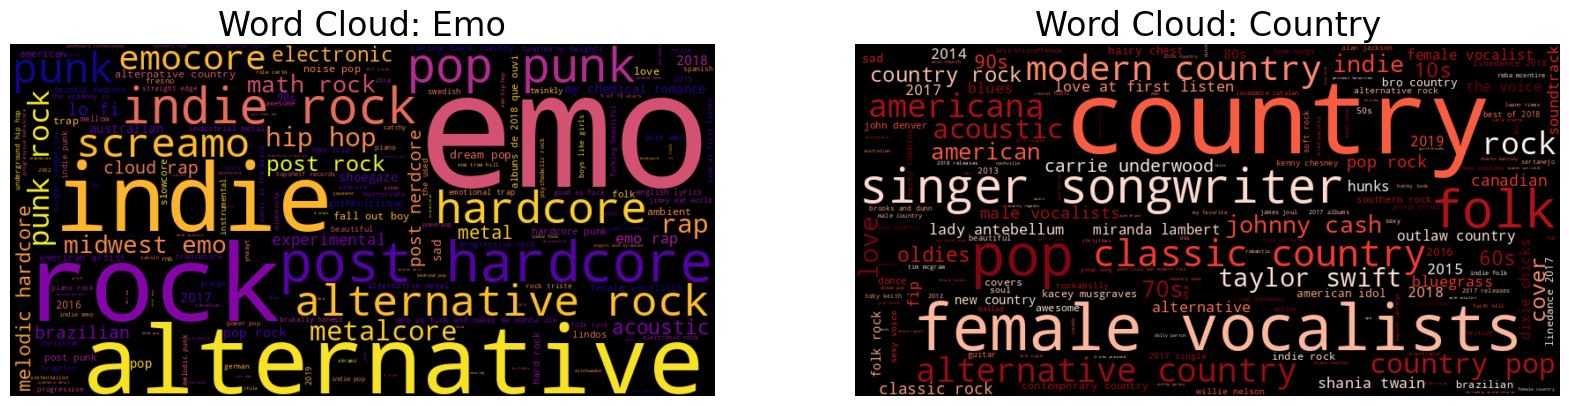

In [ ]:
from wordcloud import WordCloud
import itertools
from collections import Counter

# merge with genres on id
df_genre_tags = pd.merge(df_id_tags, df_merged[['id', 'genre']], on='id', how='inner')

# select 2 genres from our 5 selected
genre1 = 'emo'
genre2 = 'country'

# filter on genre1 by finding the rows which have this genre
mask_genre1 = df_genre_tags['genre'].apply(lambda genres_list: genre1 in genres_list)
tags_genre1 = df_genre_tags[mask_genre1]['tags'] # tags of songs belonging to genre1
tags_genre1 = list(itertools.chain.from_iterable(tags_genre1)) # put them all in a list
freq_genre1 = Counter(tags_genre1) # and measure their frequency

# filter on genre2
mask_genre2 = df_genre_tags['genre'].apply(lambda genres_list: genre2 in genres_list)
tags_genre2 = df_genre_tags[mask_genre2]['tags']
tags_genre2 = list(itertools.chain.from_iterable(tags_genre2))
freq_genre2 = Counter(tags_genre2)

# create the word clouds from the frequencies
wc1 = WordCloud(width=800, height=400, background_color='black', colormap='plasma', random_state=100).generate_from_frequencies(freq_genre1)
wc2 = WordCloud(width=800, height=400, background_color='black', colormap='Reds', random_state=100).generate_from_frequencies(freq_genre2)

# and plot
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# 1st wordcloud
axes[0].imshow(wc1, interpolation='bilinear')
axes[0].set_title(f'Word Cloud: {genre1.capitalize()}', fontsize=24)
axes[0].axis('off')

# 2nd
axes[1].imshow(wc2, interpolation='bilinear')
axes[1].set_title(f'Word Cloud: {genre2.capitalize()}', fontsize=24)
axes[1].axis('off')

plt.show()

## Εξηγηση Wordcloud

Στα παραπανω word clouds βλεπουμε τα πιο συχνα tags που οι ακροατες χρησιμοποιησαν για να περιγραψουν τα τραγουδια 2 διαφορετικων ειδων μουσικης

Στο word cloud Country παρατηρουμε να υπαρχουν tags της χωρας προελευσης τετοιας μουσικης (Αμερικής) καθως και ορισμενα που περιγραφουν σαν κατι παραδοσιακο και παλιο.

Στο word cloud emo παρατηρουμε απο την αλλη οτι κυριαρχουν συναισθηματικα φορτισμενα tags καθως και πολλα που τονιζουν την σχεση της με την ροκ μουσικη καθως αυτην ειναι υποειδος της



## Bar Chart

10 most common tags in the entire dataset (from the genres we kept)

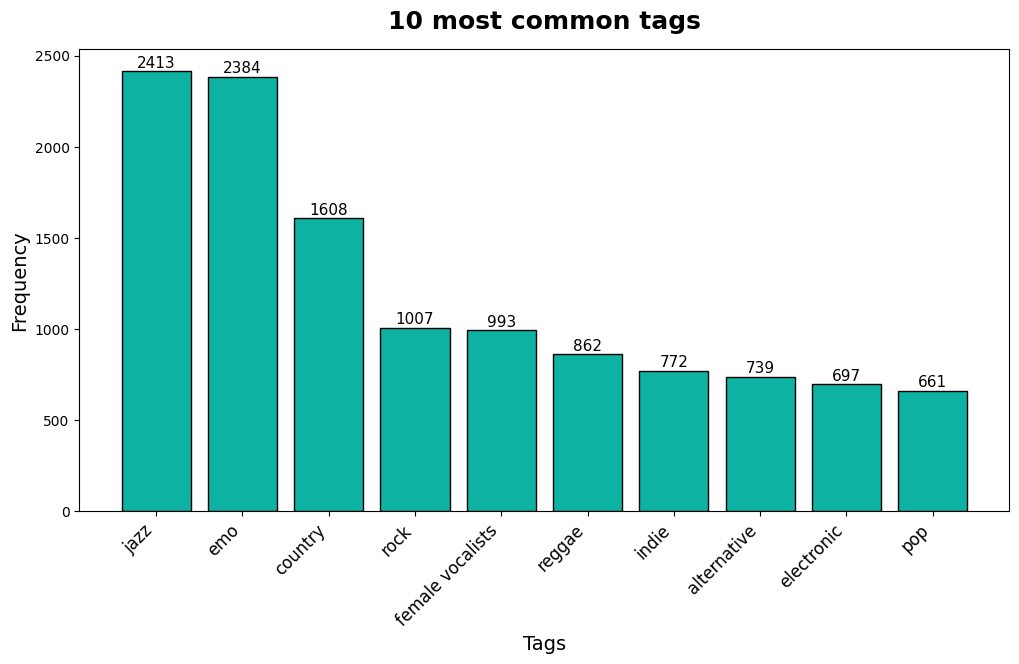

In [ ]:
# get all tags in a list and measure their frequencies (of each tag)
all_tags = list(itertools.chain.from_iterable(df_id_tags['tags']))
tags_count = Counter(all_tags)

# get the top 10 and their labels/values
top_10_tags = tags_count.most_common(10)

labels = [item[0] for item in top_10_tags]
values = [item[1] for item in top_10_tags]

# plot bar chart
plt.figure(figsize=(12, 6))

bars = plt.bar(labels, values, color='#0db2a2', edgecolor='black')
plt.title('10 most common tags', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Tags', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)

# append frequency on top of the bar
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 5, int(y),
             ha='center', va='bottom', fontsize=11)

plt.show()

##Εξηγηση Bar chart top 10 most common tags

Στο παραπανω διαγραμμα βλεπουμε την κατανομη των 10 πιο συχνα εμφανιζομενων tags σε ολο το dataset.

Παρατηρουμε οτι υπερεχουν tags οπως το jazz emo και country εναντι πασιγνωστων ορων οπως pop που αυτο σημαινει οτι το τελικο δειγμα μας αποτελειτε κυριως απο τετοιων ειδων τραγουδια

Επισης παρατηρουμε οτι το female vocalists βρισκεται στην 5η θεση, πιο πανω απο γνωστα μουσικα ειδη που εινα στις χαμηλοτερες θεσεις. Επομενως μπορουμε να βγαλουμε το συμπερασμα οτι οι ακροατες δινουν εμφαση, οχι μονο στα ακουστικα χαρακτηριστικα ή στο ειδος της μουσικης, αλλα και στο υφος και το φυλλο των καλλιτεχνων

# Instrumental Analysis

Measure the frequency of songs that are instrumental in each genre

In [47]:
# keep our 5 genres from each song (explode to count overlapping genres)
all_exploded = df_merged.explode('genre')
all_exploded = all_exploded[all_exploded['genre'].isin(my_genres)]
total_counts = all_exploded['genre'].value_counts()

# keep and count instrumentals per genre
instrumental_df = df_merged[df_merged['lyrics'] == 'instrumental'].copy()
instrumental_exploded = instrumental_df.explode('genre')
instrumental_exploded = instrumental_exploded[instrumental_exploded['genre'].isin(my_genres)]
instrumental_counts = instrumental_exploded['genre'].value_counts()

percentage_per_genre = (instrumental_counts / total_counts) * 100

results_df = pd.DataFrame({
    'Total Songs': total_counts,
    'Instrumental Count': instrumental_counts.fillna(0).astype(int),
    'Percentage (%)': percentage_per_genre.fillna(0).round(2)
})
results_df = results_df.sort_values(by='Percentage (%)', ascending=False)

print("--- Instrumental Songs vs Total Songs per Genre ---")
print(results_df.to_string())

--- Instrumental Songs vs Total Songs per Genre ---
         Total Songs  Instrumental Count  Percentage (%)
genre                                                   
techno           646                 318           49.23
jazz            2413                 740           30.67
reggae           862                  29            3.36
emo             2384                  62            2.60
country         1608                  37            2.30


# Εξήγηση instrumental analysis

Από τον παραπάνω πίνακα παρατηρούμε ότι η techno και η jazz κυριαρχούν στα instrumental κομμάτια, με την techno μάλιστα να αποτελείται σχεδόν κατά το μισό (49.2%) από καθαρά instrumental μουσική. Αντιθέτως, είδη όπως η Reggae, η Emo και η Country έχουν ελάχιστα instrumental κομμάτια (κάτω από 3.5%), γεγονός που επιβεβαιώνει ότι βασίζονται παραπάνω στον στοίχους.

## t-SNE Dimensionality reduction and scatter plots

2D Scatter plots of the songs belonging to our 5 genres, colored by genre, based on the text and audio embeddings

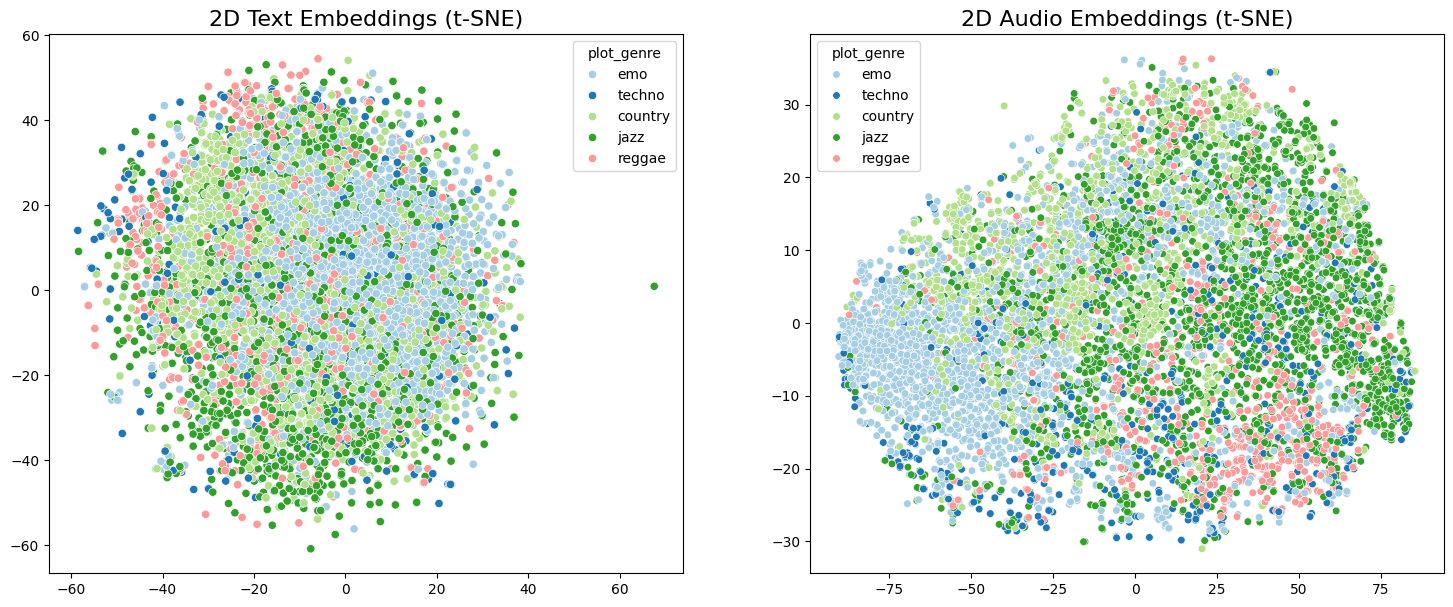

In [ ]:
import seaborn as sns
from sklearn.manifold import TSNE

# from each song get the genre that belongs to our 5 genres
def get_plot_genre(genre_list):
    if not isinstance(genre_list, list):
        return genre_list if genre_list in my_genres else 'other'

    common = [g for g in genre_list if g in my_genres]

    return common[0] if common else 'other' # assume and take the first one only (if more than 2 appear)

df_merged['plot_genre'] = df_merged['genre'].apply(get_plot_genre)

# list to array of the embeddings
text_embeddings = np.vstack(df_merged['text_embedding'].values)
audio_embeddings = np.vstack(df_merged['audio_embedding'].values)

# apply t-SNE for 2 dimensions
tsne = TSNE(n_components=2, random_state=100)

# this takes time
text_2d = tsne.fit_transform(text_embeddings)
audio_2d = tsne.fit_transform(audio_embeddings)


# create the scatter plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(x=text_2d[:,0], y=text_2d[:,1], hue=df_merged['plot_genre'],
                palette='Paired', ax=axes[0])
axes[0].set_title('2D Text Embeddings (t-SNE)', fontsize=16)

sns.scatterplot(x=audio_2d[:,0], y=audio_2d[:,1], hue=df_merged['plot_genre'],
                palette='Paired', ax=axes[1], s=30)
axes[1].set_title('2D Audio Embeddings (t-SNE)', fontsize=16)

plt.show()

# Εξηγηση scatter plots

* **2D Text Embeddings:** Εδω παρατηρουμε πως δεν υπαρχουν ιδιαιτερα εμφανές και διακριτές συστάδες, παρά μόνο για τα είδη emo και jazz που τεινουν να σχηματισουν μια συσταδα προς τα δεξια και κατω, αντίστοιχα, της μαζας. Γενικά, ολα τα τραγούδια, ανεξαρτήτως είδους, συγκεντρώνονται σε μια ενιαία και πυκνή μάζα με έντονη αλληλεπικάλυψη των χρωμάτων.

* **2D Audio Embeddings:** Αντιθέτως, με τον ήχο υπάρχει μια σαφή τάση σχηματισμού συστάδων. Τα σημεία που ανήκουν στο ίδιο είδος (χρώμα) ομαδοποιούνται δημιουργώντας διακριτές γειτονιές στον 2D χώρο. Αν και υπάρχει αναμενόμενη αλληλεπικάλυψη στα όρια των ειδών, οι πυρήνες των clusters είναι αρκετά ξεκάθαροι.

Επομένως είναι φανερό ότι το modality του ήχου (Audio Embeddings) διαχωρίζει καλύτερα τις μουσικές κλάσεις.

Το παραπανω οφειλεται στο γεγονος πως τα Audio Embeddings συλλαμβάνουν πιο βαθιές θεματικές διαφορές καθώς τα είδη στο dataset μας εχουν μεταξύ τους εντελώς διαφορετικό ήχο (π.χ. emo με jazz, emo με reggae). Αντιθέτως, τα Text Embeddings δεν ειναι ακριβή καθώς, για παράδειγμα, τα είδη techno και jazz, όπως αποδείχτηκε παραπάνω, αποτελούνται απο αρκετά instrumental τραγούδια με αποτέλεσμα να βρίσκονται παντού στην μάζα.

## Genre Variety

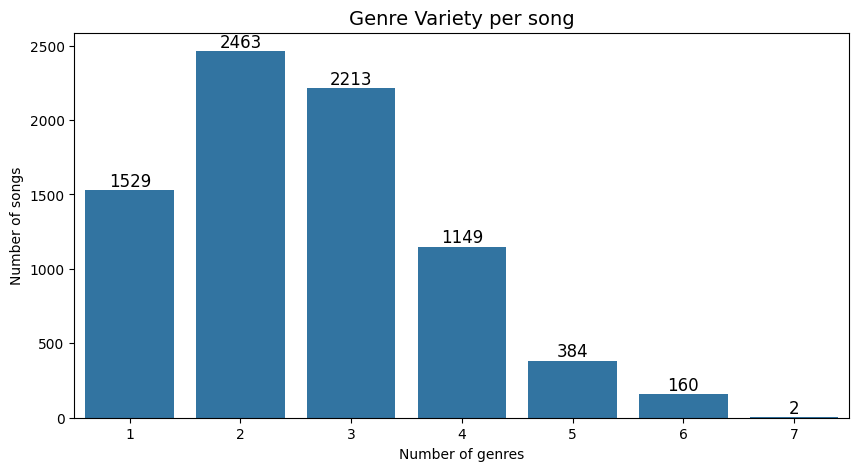

In [ ]:
df_merged['genres_count'] = df_merged['genre'].apply(lambda x: len(x) if isinstance(x, list) else 1)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_merged, x='genres_count')
plt.title('Genre Variety per song', fontsize=14)
plt.xlabel('Number of genres')
plt.ylabel('Number of songs')

# show number of songs above the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=12, color='black')

plt.show()

df_merged = df_merged.drop(columns=['genres_count'])

##Εξηγηση ποικιλιας ειδων

Στο παραπανω διαγραμμα βλεπουμε σε ποσα μουσικα ειδη ταξινομουνται τα τραγουδια του dataset. Παρατηρειται οτι τα πειρσσοτερα τραγουδια ανηκουν σε 2  ή 3 ειδη, στην συνεχεια κυριαρχει το 1 και τελος μειωνονται φανερα τα τραγουδια που ανηκουν σε 4 ή περισσοτερα genres

Αυτο εξηγει απολυτα την πεποιθηση οτι δεν γινεται να οριοθετηθει η μουσικη απολυτα, ειτε επειδη ο καλλιτεχνης δεν επιλεγει ενα ειδος και τελος αλλα η μουσικη του συνηθως παλλεται μεταξυ καποιων ειδων (συνηθως 2-3) ειτε επειδη αυτη η κατηγοριοποιηση προκυπτει απο tags ακροατων οπου ο υποκειμενισμος υπερισχυει. Δηλαδη ο καθε ανθρωπος αντιλαμβανεται διαφορετικα το καθε τραγουδι με αποτελεσμα να το καταττασει σε κατι διαφορετικο απο καποιον αλλον


## Songs per genre

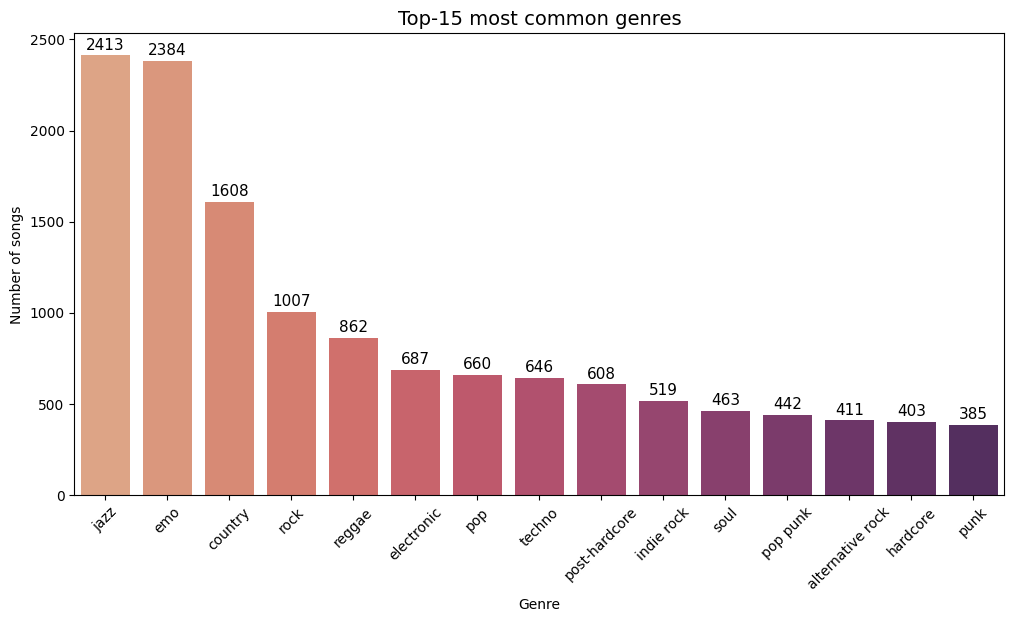

In [ ]:
# explode genre column in order to count that song for all of its genres
df_exploded_genres = df_merged.explode('genre')

top_n = 15
top_n_genres = df_exploded_genres['genre'].value_counts().head(top_n)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_n_genres.index, y=top_n_genres.values, hue=top_n_genres.index, palette='flare')
plt.title(f'Top-{top_n} most common genres', fontsize=14)
plt.xlabel('Genre')
plt.ylabel('Number of songs')
plt.xticks(rotation=45)

# count number above bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2, fontsize=11)

plt.show()

##Εξηγηση top 15 most common genres

Στο παραπανω διαγραμμα παρουσιαζονται τα 15 κορυφαια ειδη μουσικης και ο αριθμος τραγουδιων καθε ειδους. Οπως ειναι λογικο πολλα τραγουδια ανηκουν σε παραπανω απο ενα ειδος οποτε χρησιμοποιησαμε την συναρτηση 'explode' για να μετρησουμε τη συνολικη εμβέλεια της καθε κατηγοριας

Οπως φαινεται την μεγαλυτερη πλειοψηφια την εχουν τα πρωτα 3 genres(Jazz, Emo, Country) με αρκετη διαφορα μαλιστα απο τα επομενα στην σειρα. Αυτο δηλωνει οτι το τελικο δειγμα μας εχει εντονη θεματικη κλιση σε τετοιου ειδους μουσικες σκηνες

Επισης παρατηρουμε οτι υπαρχουν αρκετες συσχετισεις μεταξυ καποιων ειδων, για παραδειγμα το emo με τα post-hardcore, pop punk, alternative rock, hardcore και punk. Συμφωνα και με τα προηγουμενα γραφηματα ειναι λογικο να συμπαιρανουμε οτι πολλα ιδια τραγουδια μοιραζονται αυτα τα genres ετσι ωστε να μεγαλωνουν τα νουμερα σε ολο το φασμα της alternative punk σκηνης

## Words and characters distribution from the lyrics

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


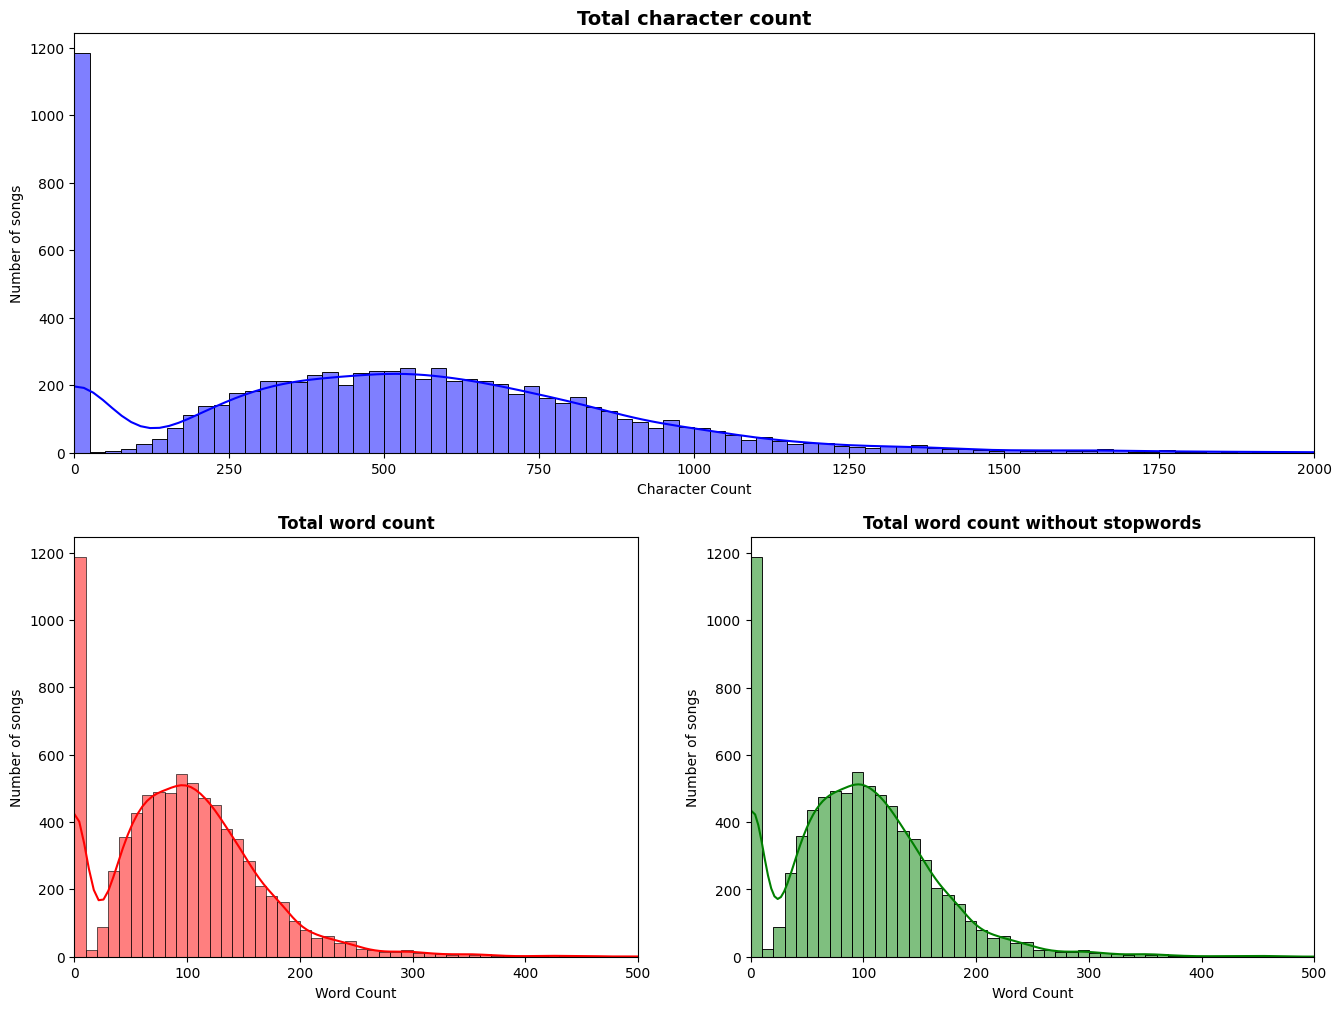

In [ ]:
import nltk
from nltk.corpus import stopwords

# download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


# get char and word counts for each non-instrumental song (instrumentals are all 0)
df_merged['char_count'] = df_merged['lyrics'].apply(lambda x: 0 if x == 'instrumental' else len(x))
df_merged['word_count'] = df_merged['lyrics'].apply(lambda x: 0 if x == 'instrumental' else len(x.split()))

# count the non-stopword words for given lyrics
def count_nonstopwords(text):
    words = text.split()
    meaningful = [w for w in words if w.lower() not in stop_words]
    return len(meaningful)

df_merged['nostopwords_word_count'] = df_merged['lyrics'].apply(count_nonstopwords)



# plot
max_words = 500
max_chars = 2000

fig = plt.figure(figsize=(16, 12))

# char graph (up and long)
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)
sns.histplot(df_merged['char_count'], bins=80, binrange=(0, max_chars),
             kde=True, color='blue', ax=ax1)
ax1.set_title('Total character count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Character Count')
ax1.set_ylabel('Number of songs')
ax1.set_xlim(0, max_chars)

# total words graph (bottom left)
ax2 = plt.subplot2grid((2, 2), (1, 0))
sns.histplot(df_merged['word_count'], bins=50, binrange=(0, max_words), kde=True, color='red', ax=ax2)
ax2.set_title('Total word count', fontsize=12, fontweight='bold')
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Number of songs')
ax2.set_xlim(0, max_words)

# no stopwords words graph (bottom right)
ax3 = plt.subplot2grid((2, 2), (1, 1))
sns.histplot(df_merged['nostopwords_word_count'], bins=50, binrange=(0, max_words),
             kde=True, color='green', ax=ax3)
ax3.set_title('Total word count without stopwords', fontsize=12, fontweight='bold')
ax3.set_xlabel('Word Count')
ax3.set_ylabel('Number of songs')
ax3.set_xlim(0, max_words)

plt.show()



df_merged = df_merged.drop(columns=['word_count'])
df_merged = df_merged.drop(columns=['char_count'])
df_merged = df_merged.drop(columns=['nostopwords_word_count'])

##Εξηγηση κατανομη μεγεθους στοιχων και stopwords

Παρατηρουμε αρχικα οτι και στα 3 διαγραμματα εχουμε μια αιχμη στο 0.Αυτο ειναι λογικο. Συμφωνα με τα προηγουμενα γραφηματα στο dataset κυριαρχουν ειδη οπως η jazz, techno κλπ, οπου πολλα απο αυτα ειναι instrumental δηλαδη χωρις καθολου στοιχους.

Επειτα απο το 0 οι κατανομες παρουσιαζουν μια θετικη λοξοτητα με την πλειοψηφια να εχει 100-200 λεξεις και αντοιστοιχα 500-1000 χαρακτηρες οπου στην συνεχεια μειωνεται για τραγουδια με παραπανω λεξεις και χαρακτηρες.Αυτο οφειλεται κυριως στους φυσικους περιορισμους της εμπορικης μουσικης. Τα περισσοτερα τραγουδια κυμαινονται απο 2 εως 4 λεπτα περιοριζοντας το λεξιλογιο να ξεφυγει απο το παραπανω οριο. Ωστοσο η πτωση προς τα δεξια δεν ειναι ακαριαια και αυτο υποδηλωνει οτι υπαρχουν εξαιρεσεις σε ειδη μουσικης οπου ο ογκος των στοιχων τους ειναι μεγαλυτερος

Τελευταια, παρατηρουμε οτι οι καμπυλες των συνολικων λεξεων με και χωρις stopwords ειναι αρκετά παρόμοιες, γεγονος που δειχνει οτι οι στοιχοι στα δοσμενα δεδομένα εχουν ηδη προεπεξεργαστει για την αφαιρεση των stopwords.


## VADER Sentiment Analysis on lyrics-genre

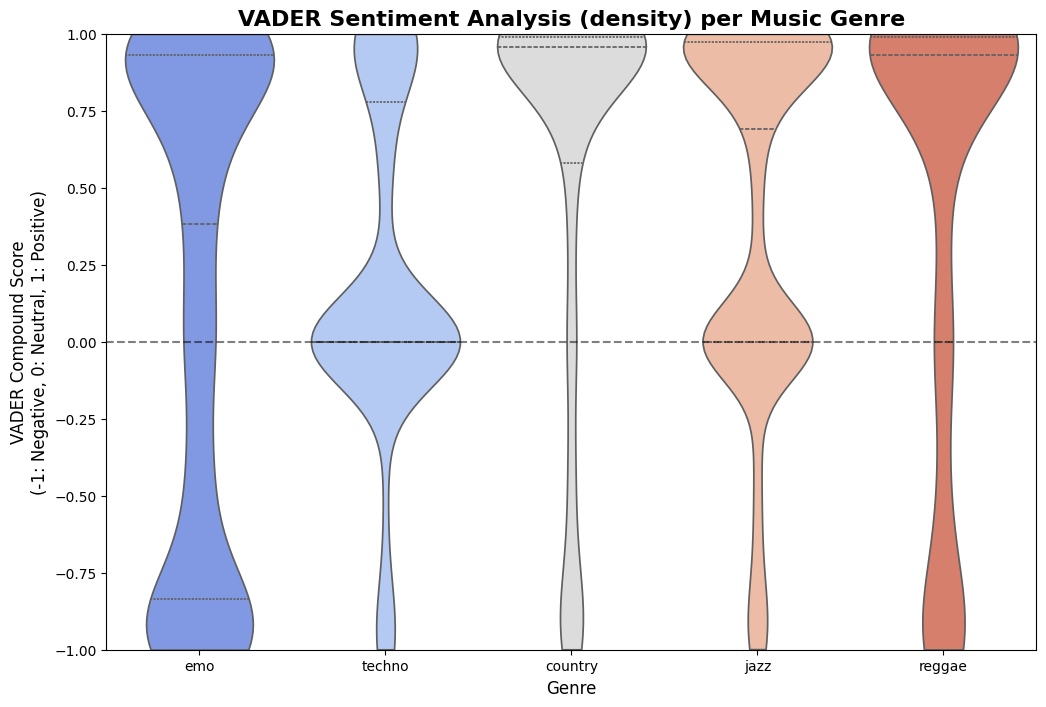

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# init vader and calculate compound score on the lyrics
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if text == 'instrumental': # assuming instrumental tracks are neutral
        return 0
    return analyzer.polarity_scores(str(text))['compound']

df_merged['vader_compound'] = df_merged['lyrics'].apply(get_sentiment)


# plot (our 5 genres only from plot_genre)
plt.figure(figsize=(12, 8))

sns.violinplot(x='plot_genre', y='vader_compound', data=df_merged, hue='plot_genre', palette='coolwarm', inner='quartile', cut=0)
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # neutral line at x = 0
plt.title('VADER Sentiment Analysis (density) per Music Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('VADER Compound Score\n(-1: Negative, 0: Neutral, 1: Positive)', fontsize=12)
plt.ylim(-1, 1)

plt.show()


df_merged = df_merged.drop(columns=['vader_compound'])

##Εξηγηση αναλυσης συναισθηματος

Στο παραπανω violin plot βλεπουμε την πυκνοτητα των σκορ συναισθηματος οπου η τιμες κυμαινονται απο -1 εως 1 δηλαδη σε Ακρως αρνητικο και Ακρως θετικο αντοιστιχα

Αρχικα το ειδος emo βλεπουμε οτι παρουζιαζει συγκεντρωση και στο πανω μερος (θετικο συναισθημα) αλλα και στο κατω (αρνητικο συναισθημα). Αυτο οφειλεται στο γεγονος πως οι στοιχοι των emo τραγουδιων περιεχουν κυριως συναισθηματικα φορτισμενες λεξεις που μπορουν να εκληφθουν, μεμονωμενες, ειτε ως θετικες ειτε ως αρνητικες.

Επειτα για το ειδος techno παρατηρουμε πως η μεγαλυτερη συγκεντρωση βρισκεται στο 0, δηλαδη με ουδετερο συναισθημα, καθως πολλα απο αυτα τα τραγουδια δεν περιεχουν στοιχους εξαρχης

Τελευταια για τα 3 τελευεταια ειδη παρατηρουμε πως τα τραγουδια τεινουν να ειναι θετικα, ή έστω ουδέτερα, αφου ειτε περιεχουν θετικα συναισθηματικα φορτισμενες λεξεις είτε ειναι instrumental κομματια (π.χ. jazz)

## Similary Analysis

In [50]:
from sklearn.metrics.pairwise import cosine_similarity

# list -> array
text_embeddings = np.vstack(df_merged['text_embedding'].values)
audio_embeddings = np.vstack(df_merged['audio_embedding'].values)

# pick a random song to test
random_index = df_merged.sample(1).index[0]
random_song = df_merged.loc[random_index]

print(f"--- Test Song Details ---")
print(f"ID: {random_song['id']}")
print(f"Genre(s): {random_song['genre']}")
if (len(random_song['lyrics']) == 'instrumental'):
    print(f'Lyrics: instrumental\n')
else:
  print(f"Lyrics: {str(random_song['lyrics'])[:200]}...\n")


# calculate cosine similarity to each other song
text_scores = cosine_similarity(text_embeddings[random_index].reshape(1, -1), text_embeddings).flatten()
audio_scores = cosine_similarity(audio_embeddings[random_index].reshape(1, -1), audio_embeddings).flatten()

# get 5 most similar songs (exclude the picked random song, which will be in index 0 after sorting)
top_5_text_indices = text_scores.argsort()[-6:-1][::-1]
top_5_audio_indices = audio_scores.argsort()[-6:-1][::-1]


# print
print("\n\n--- Top 5 similar songs by TEXT (Lyrics) ---")
print(df_merged.loc[top_5_text_indices, ['id', 'genre']].to_string(index=False))

print("\n--- Top 5 similar songs by AUDIO (Sound) ---")
print(df_merged.loc[top_5_audio_indices, ['id', 'genre']].to_string(index=False))

--- Test Song Details ---
ID: fw4e4X87bhmbhctK
Genre(s): ['trance', 'electronic', 'techno']
Lyrics: till till chang it and see till till till chang it and see till till chang it and see till till till chang it and see till till till chang it and see...



--- Top 5 similar songs by TEXT (Lyrics) ---
              id                                                       genre
fw4e4X87bhmbhctK                                [trance, electronic, techno]
9bxuYQ4fJlFwdLMZ                  [post-hardcore, hardcore, electronic, emo]
YuSAfsSdxBPLySTd                      [post-hardcore, screamo, emo, emocore]
yRX83sdbxIuoa0u1 [post-hardcore, screamo, hardcore, emocore, metalcore, emo]
WuTDTn6hpdYoNKVY                                       [pop punk, rock, emo]

--- Top 5 similar songs by AUDIO (Sound) ---
              id                                           genre
zXyXsfH0wLl7c3JT                    [trance, electronic, techno]
tvVsXtFfFyBIyw8e [techno, electronic, ambient techno, breakbe

# Εξηγηση cosine similarity


Ελεγχοντας διαφορα τραγουδια, παρατηρουμε οτι οι στίχοι (Text Embeddings) από μόνοι τους συχνά δεν αρκούν για να ξεχωρίσουν τα είδη μουσικής, καθώς κοινά θέματα, όπως η αγάπη ή ο θυμός, και οι σχετικες λεξεις συναντώνται παντού, από την emo μέχρι την country, με αποτελέσμα τα παρόμοια τραγουδια να μην εχουν παντα κοινα genres. Αντίθετα, τα χαρακτηριστικά του ήχου (Audio Embeddings) αποδεικνύονται πολύ πιο αξιόπιστα, ειδικά σε είδη με έντονη μουσική ταυτότητα, όπως το techno, καθως οι ηχοι ειναι λιγότερο πιθανό να συγχεονται μεταξυ των ειδών σε σχεση με τους στοιχους.